# 05 - Product & Seller Analysis
Cross-checks `sql/04_product_analysis.sql` and `sql/05_seller_analysis.sql`: which categories and sellers drive the business, and where quality or logistics risk concentrates.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as mticker, seaborn as sns
sns.set_theme(style="whitegrid", context="notebook"); pd.set_option("display.width", 160)
ROOT = Path("..").resolve(); SQL = ROOT / "reports" / "sql_results"
def brl(x, pos=None): return f"R${x/1000:,.0f}k" if abs(x) >= 1000 else f"R${x:,.0f}"

## Q1. Which categories generate the most revenue, and how concentrated is it (Pareto)?

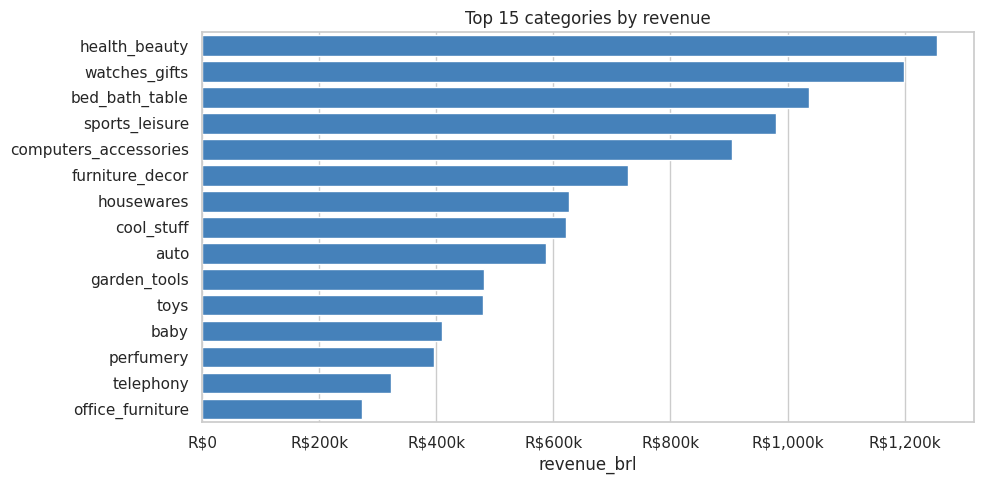

18 of 74 categories (24%) generate 80% of revenue


In [2]:
cat = pd.read_csv(SQL / "04_product_analysis__category_performance.csv").sort_values("revenue_brl", ascending=False)
pareto = pd.read_csv(SQL / "08_advanced_analysis__pareto_summary.csv").iloc[0]
fig, ax = plt.subplots(figsize=(10, 5))
top = cat.head(15)
sns.barplot(data=top, y="category_en", x="revenue_brl", color="#3182ce", ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(brl)); ax.set_title("Top 15 categories by revenue"); ax.set_ylabel("")
plt.tight_layout(); plt.savefig(ROOT/"reports"/"figures"/"top_categories_revenue.png", dpi=110); plt.show()
print(f"{pareto.categories_for_80pct_revenue} of {pareto.total_categories} categories ({pareto.categories_for_80pct_revenue/pareto.total_categories:.0%}) generate 80% of revenue")

**Finding:** health & beauty, watches/gifts, bed/bath/table and sports/leisure lead revenue; 18 of 74 categories (24%) generate 80% of revenue - a classic Pareto pattern but less extreme than a typical single-brand catalogue, because Olist is a multi-category marketplace. **Implication:** the top ~20 categories deserve priority for inventory, promotions and seller-support investment; the long tail of 56 categories contributes only 20% of revenue between them.

## Q2. Which categories carry the heaviest freight burden relative to price?

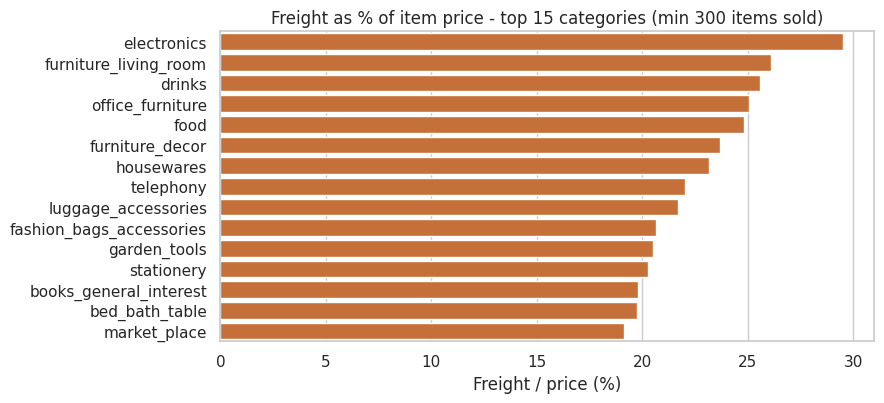

In [3]:
fr = pd.read_csv(SQL / "04_product_analysis__high_freight_categories.csv")
fig, ax = plt.subplots(figsize=(9, 4.2))
sns.barplot(data=fr, y="category_en", x="freight_pct_of_price", color="#dd6b20", ax=ax)
ax.set_title("Freight as % of item price - top 15 categories (min 300 items sold)"); ax.set_ylabel(""); ax.set_xlabel("Freight / price (%)")
plt.tight_layout(); plt.savefig(ROOT/"reports"/"figures"/"freight_burden_categories.png", dpi=110); plt.show()

**Finding:** bulky/heavy categories (furniture, office supplies, construction) show freight running 30-60%+ of item price, while small high-value goods carry much lower relative freight. **Implication:** for these categories, freight is a real barrier to conversion; consider regional fulfillment or freight-inclusive pricing to stay competitive.

## Q3. Do any high-volume products have systematically poor reviews?

In [4]:
poor = pd.read_csv(SQL / "04_product_analysis__high_sales_poor_reviews.csv")
print(f"{len(poor)} products with >=30 orders and an average review below 3.5 stars")
poor[["product_id","category_en","orders","revenue_brl","avg_review_score","pct_reviews_1_2_stars"]].head(10)

20 products with >=30 orders and an average review below 3.5 stars


,product_id,category_en,orders,revenue_brl,avg_review_score,pct_reviews_1_2_stars
0,25c38557cf793876c5abdd5931f922db,baby,38,38907.32,2.68,54.1
1,1dec4c88c685d5a07bf01dcb0f8bf9f8,auto,35,19965.00,2.74,50.0
2,e53e557d5a159f5aa2c5e995dfdf244b,computers_accessories,156,15439.25,3.45,31.7
3,8ed094bfe076c568f6bb10feada3f75d,office_furniture,49,12947.09,3.44,25.7
4,36f60d45225e60c7da4558b070ce4b60,computers_accessories,111,11240.96,3.20,37.3
5,2ffdf10e724b958c0f7ea69e97d32f64,watches_gifts,52,10916.60,3.25,31.4
6,84f456958365164420cfc80fbe4c7fab,bed_bath_table,106,10304.96,3.30,29.0
7,2a5806f10d0f00e5ad032dd2e3c8806e,office_furniture,53,9421.45,3.28,31.5
8,b114bf337c0626166abe574eee9e3f32,office_furniture,30,8348.00,3.22,33.3
9,b5e13c9a353102f79c6206ff5cb61a50,toys,83,7810.90,2.89,45.1


**Finding:** a small set of high-volume products combine real revenue with weak satisfaction (many with 30%+ of reviews at 1-2 stars). **Implication:** these are prime candidates for a quality audit - a listing/description mismatch or a packaging problem is more likely than one-off bad luck, given the volume involved.

## Q4. Price bands: where does the money come from, and is satisfaction consistent across them?

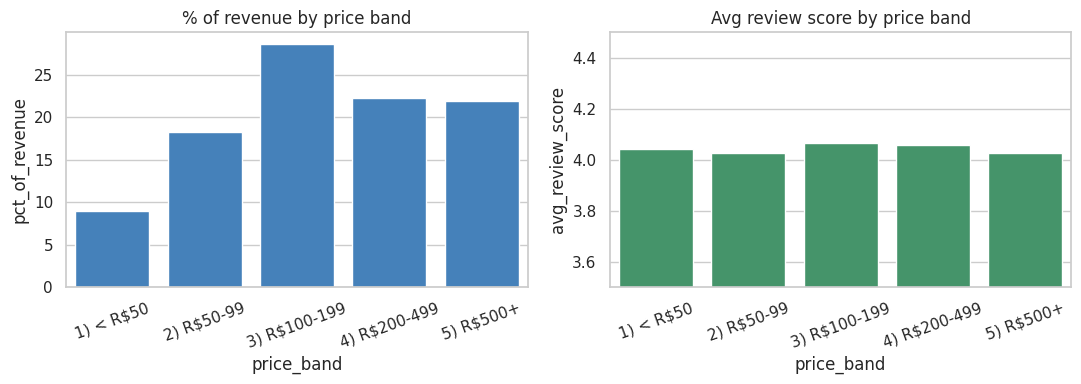

In [5]:
pb = pd.read_csv(SQL / "04_product_analysis__price_band_performance.csv")
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=pb, x="price_band", y="pct_of_revenue", color="#3182ce", ax=ax[0]); ax[0].set_title("% of revenue by price band"); ax[0].tick_params(axis="x", rotation=20)
sns.barplot(data=pb, x="price_band", y="avg_review_score", color="#38a169", ax=ax[1]); ax[1].set_title("Avg review score by price band"); ax[1].set_ylim(3.5, 4.5); ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.savefig(ROOT/"reports"/"figures"/"price_band_performance.png", dpi=110); plt.show()

**Finding:** mid-range items (R$50-199) drive the bulk of revenue; review scores are broadly stable across price bands, so satisfaction is not simply a function of price. **Implication:** quality issues found in Q3 are product-specific, not a general 'cheap = bad reviews' pattern.

## Q5. Seller concentration - how much of the business rides on a few sellers?

/tmp/ipykernel_217/2028299199.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  sns.barplot(data=top.head(10), y="seller_id", x="revenue_brl", color="#3182ce", ax=ax[1]); ax[1].set_yticklabels([f"seller_{i+1}" for i in range(10)]); ax[1].xaxis.set_major_formatter(mticker.FuncFormatter(brl))


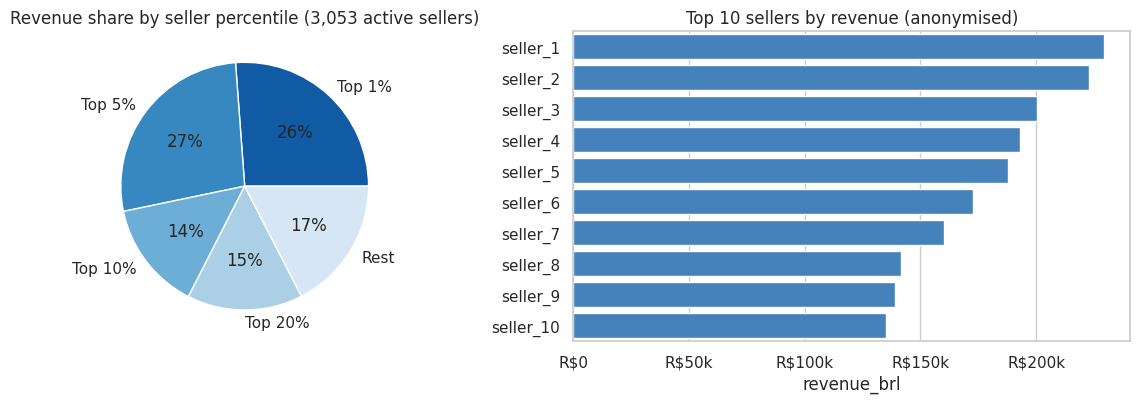

In [6]:
conc = pd.read_csv(SQL / "05_seller_analysis__seller_concentration.csv").iloc[0]
top = pd.read_csv(SQL / "05_seller_analysis__top_sellers_by_revenue.csv")
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
labels = ["Top 1%", "Top 5%", "Top 10%", "Top 20%", "Rest"]
vals = [conc.top_1pct_share, conc.top_5pct_share - conc.top_1pct_share, conc.top_10pct_share - conc.top_5pct_share, conc.top_20pct_share - conc.top_10pct_share, 100 - conc.top_20pct_share]
ax[0].pie(vals, labels=labels, autopct="%1.0f%%", colors=sns.color_palette("Blues_r", 5)); ax[0].set_title(f"Revenue share by seller percentile ({conc.active_sellers:,.0f} active sellers)")
sns.barplot(data=top.head(10), y="seller_id", x="revenue_brl", color="#3182ce", ax=ax[1]); ax[1].set_yticklabels([f"seller_{i+1}" for i in range(10)]); ax[1].xaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax[1].set_title("Top 10 sellers by revenue (anonymised)"); ax[1].set_ylabel("")
plt.tight_layout(); plt.savefig(ROOT/"reports"/"figures"/"seller_concentration.png", dpi=110); plt.show()

**Finding:** the top 1% of sellers (about 31 sellers) generate roughly a quarter of all revenue, and the top 10% generate over two-thirds. **Implication:** the marketplace has a classic power-law seller base - losing a handful of top sellers would be a material revenue risk, so seller-retention and performance support should be prioritised for this small group.

## Q6. Does seller size relate to delivery/review quality?

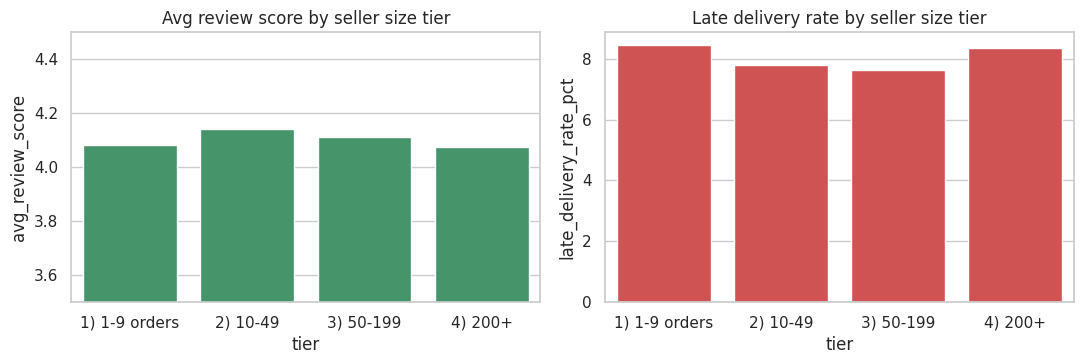

In [7]:
tiers = pd.read_csv(SQL / "05_seller_analysis__seller_volume_tiers.csv")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
sns.barplot(data=tiers, x="tier", y="avg_review_score", color="#38a169", ax=ax[0]); ax[0].set_title("Avg review score by seller size tier"); ax[0].set_ylim(3.5, 4.5)
sns.barplot(data=tiers, x="tier", y="late_delivery_rate_pct", color="#e53e3e", ax=ax[1]); ax[1].set_title("Late delivery rate by seller size tier")
plt.tight_layout(); plt.savefig(ROOT/"reports"/"figures"/"seller_size_quality.png", dpi=110); plt.show()

**Finding:** the largest sellers (200+ orders) tend to have both better review scores and lower late-delivery rates than the smallest tier. **Implication:** scale seems to bring operational maturity in this marketplace; smaller/newer sellers may benefit from onboarding support on shipping SLAs.